In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from sklearn.datasets import fetch_california_housing

In [ ]:
data=fetch_california_housing()

In [ ]:
df=pd.DataFrame(data.data,columns=data.feature_names)

In [ ]:
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [ ]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [ ]:
df['price']=data.target

In [ ]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


<Axes: >

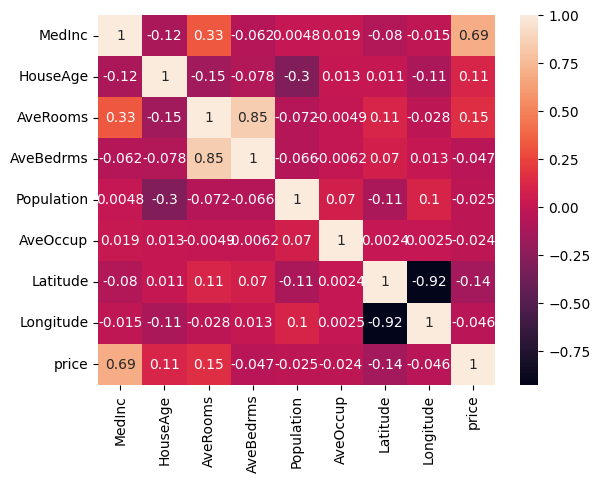

In [ ]:
sns.heatmap(df.corr(),annot=True)

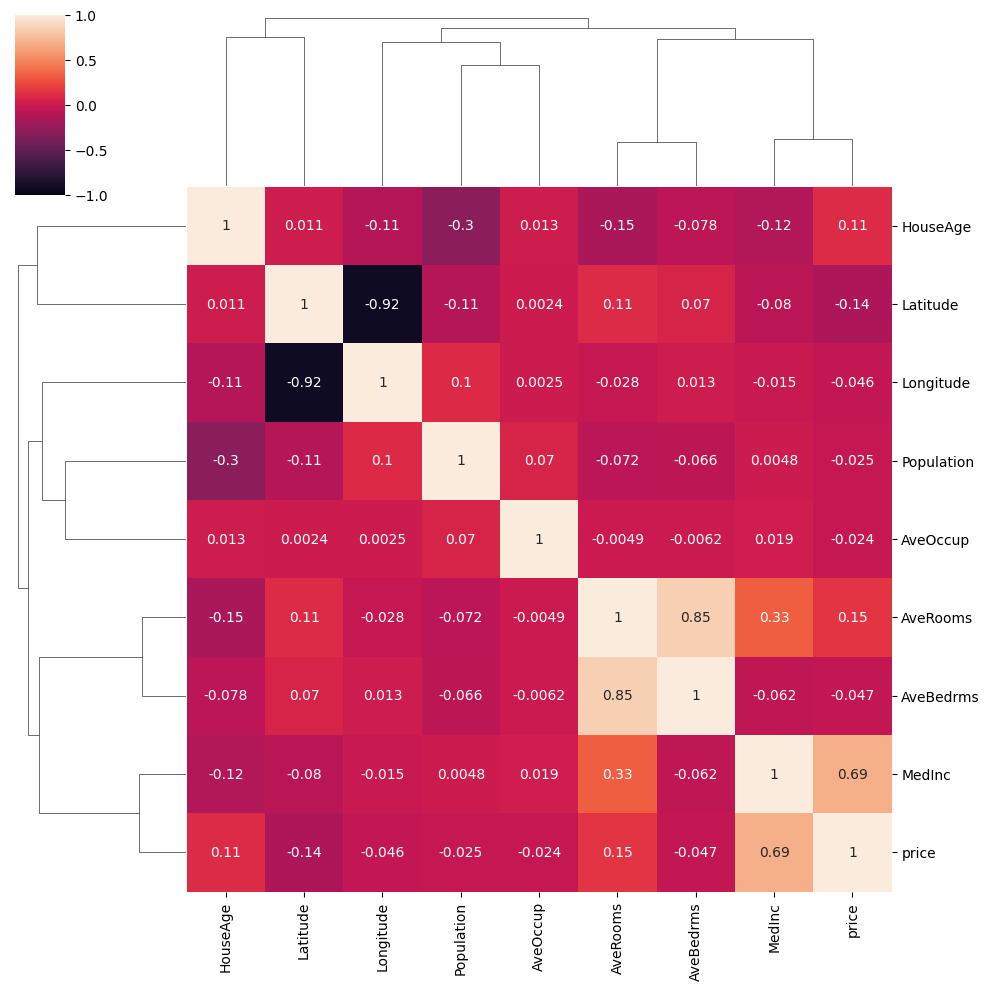

In [ ]:
sns.clustermap(df.corr(),vmin=-1,vmax=1,annot=True)

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [ ]:
vif=pd.DataFrame()
vif['Feature']=df.columns
vif['VIF']=[variance_inflation_factor(df.values,i) for i in range(len(df.columns))]

In [ ]:
vif

,Feature,VIF
0,MedInc,19.624998
1,HouseAge,7.592663
2,AveRooms,47.956351
3,AveBedrms,45.358192
4,Population,2.936078
5,AveOccup,1.099530
6,Latitude,568.497332
7,Longitude,640.064211
8,price,9.285659


In [ ]:
df1=df.copy()

In [ ]:
df1.drop("Longitude",axis=1,inplace=True)

In [ ]:
vif=pd.DataFrame()
vif['Feature']=df1.columns
vif['VIF']=[variance_inflation_factor(df1.values,i) for i in range(len(df1.columns))]

In [ ]:
vif

,Feature,VIF
0,MedInc,18.639889
1,HouseAge,7.346583
2,AveRooms,44.714760
3,AveBedrms,42.072000
4,Population,2.796280
5,AveOccup,1.099394
6,Latitude,22.873934
7,price,9.193500


In [ ]:
df1.drop("AveRooms",axis=1,inplace=True)

In [ ]:
vif=pd.DataFrame()
vif['Feature']=df1.columns
vif['VIF']=[variance_inflation_factor(df1.values,i) for i in range(len(df1.columns))]

In [ ]:
vif

,Feature,VIF
0,MedInc,10.584081
1,HouseAge,7.260588
2,AveBedrms,6.440667
3,Population,2.762794
4,AveOccup,1.098719
5,Latitude,22.094483
6,price,8.674858


In [ ]:
df1.drop("Latitude",axis=1,inplace=True)

In [ ]:
vif=pd.DataFrame()
vif['Feature']=df1.columns
vif['VIF']=[variance_inflation_factor(df1.values,i) for i in range(len(df1.columns))]

In [ ]:
vif

,Feature,VIF
0,MedInc,8.855104
1,HouseAge,4.156145
2,AveBedrms,4.264253
3,Population,2.223926
4,AveOccup,1.098671
5,price,8.607339


In [ ]:
x=df1.drop("price",axis=1)
y=df1["price"]

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=1)

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler=StandardScaler()

In [ ]:
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
model=LinearRegression()

In [ ]:
model

LinearRegression()

In [ ]:
model.fit(x_train,y_train)

LinearRegression()

In [ ]:
model.coef_

array([ 0.8295202 ,  0.23888438,  0.02058888,  0.03902186, -0.05185743])

In [ ]:
model.intercept_

np.float64(2.0765314825581394)

In [ ]:
y_pred=model.predict(x_test)

In [ ]:
error=y_test-y_pred

<Axes: xlabel='price', ylabel='Density'>

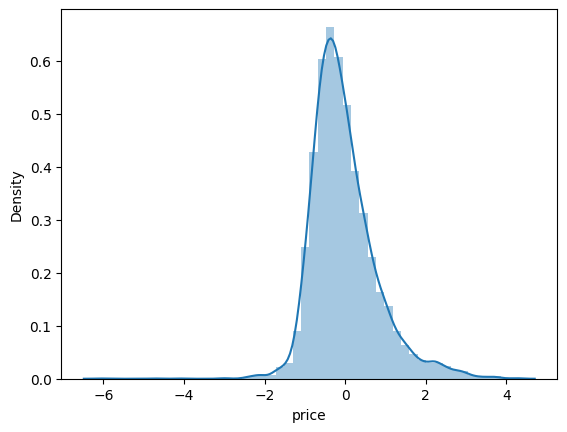

In [ ]:
sns.distplot(error)

In [ ]:
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

In [ ]:
mean_absolute_error(y_test,y_pred)

0.6046846522578226

In [ ]:
mean_squared_error(y_test,y_pred)

0.6544937093127863

In [ ]:
r2_score(y_test,y_pred)

0.502166171877851

In [ ]:
# RFE (Recursive Feature Elimination) implementation

In [ ]:
x=df.drop("price",axis=1)
y=df["price"]

In [ ]:
from sklearn.feature_selection import RFE

In [ ]:
rfe=RFE(estimator=LinearRegression(),n_features_to_select=5)

In [ ]:
rfe

RFE(estimator=LinearRegression(), n_features_to_select=5)

In [ ]:
rfe.fit(x,y)

RFE(estimator=LinearRegression(), n_features_to_select=5)

In [ ]:
rfe.support_

array([ True, False,  True,  True, False, False,  True,  True])

In [ ]:
x.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude'],
      dtype='object')

In [ ]:
y_pred=rfe.predict(x) # x is given directly beacuse we did not break it into train test .

In [ ]:
y_pred

array([3.98910415, 4.03191679, 3.44103761, ..., 0.22630645, 0.36574672,
       0.57907858])

In [ ]:
# manuallly it can be different like in vif feature selected are different and in RFE are different